<a href="https://colab.research.google.com/github/Nkeh/ml-algorithms/blob/main/knn_iris_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problem 4: Iris Species Classification — K-Nearest Neighbours (KNN)

**Course ML Project | Model 4 of 4**

---

### Pipeline
1. Scope & Problem Definition
2. Data Acquisition
3. Cleaning & Preprocessing
4. Exploratory Data Analysis (EDA)
5. Feature Engineering
6. **Model Selection** ← the key step
7. Model Training
8. Evaluation & Tuning
9. PCA Extension

---
## Step 1 — Scope & Problem Definition

**Goal:** Classify an iris flower into one of three species — *Setosa*, *Versicolor*, or *Virginica* — based on measurements of its petals and sepals.

| Property | Detail |
|---|---|
| Task type | Supervised **multi-class classification** (3 classes) |
| Target variable | `species` — 0=Setosa, 1=Versicolor, 2=Virginica |
| Input features | 4 continuous measurements (cm): sepal length/width, petal length/width |
| Dataset | Iris Dataset — 150 samples, perfectly balanced (50 per class) |

### Why this problem calls for KNN

The core insight is **geometric**: the three iris species form well-separated clusters in 4-dimensional feature space. A flower that is close (in measurement space) to known Versicolor samples is almost certainly a Versicolor.

KNN exploits this directly. It makes **no assumptions** about the shape of the decision boundary — it simply says:

> *"Look at the $k$ training points closest to this new sample. Whichever class the majority belong to, that is the prediction."*

This is called a **non-parametric, instance-based** model. There is no explicit training phase — the model IS the training data. Every prediction is made at query time by searching for neighbours.

The dataset also has:
- **Small, low-dimensional feature space** (150 samples, 4 features) — ideal for KNN, which degrades in high dimensions
- **Perfectly balanced classes** — no class imbalance to correct
- **Continuous numeric features** — Euclidean distance is well-defined
- **Clear cluster structure** — confirmed visually in EDA

---
## Step 2 — Data Acquisition

The Iris dataset was introduced by statistician Ronald Fisher in 1936. It is built into `sklearn.datasets` — no download needed.

| Feature | Description |
|---|---|
| `sepal length (cm)` | Length of the sepal (outer leaf) |
| `sepal width (cm)` | Width of the sepal |
| `petal length (cm)` | Length of the petal (inner leaf) |
| `petal width (cm)` | Width of the petal |
| `target` | **0 = Setosa, 1 = Versicolor, 2 = Virginica** |

In [ ]:
# ── Imports ───────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import seaborn as sns
from scipy import stats
from sklearn.datasets import load_iris
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11
})

BLUE  = '#378ADD'
CORAL = '#D85A30'
TEAL  = '#1D9E75'
AMBER = '#BA7517'
PURP  = '#7F77DD'
GRAY  = '#888780'

SPECIES_COLORS = [BLUE, CORAL, TEAL]
SPECIES_NAMES  = ['Setosa', 'Versicolor', 'Virginica']

print('Libraries loaded.')

Libraries loaded.


In [ ]:
# ── Load data ─────────────────────────────────────────────────────────────────
iris   = load_iris(as_frame=True)
df_raw = iris.frame.copy()
df_raw.columns = iris.feature_names + ['target']

# Rename columns for convenience
df_raw.columns = ['sepal_length', 'sepal_width',
                   'petal_length', 'petal_width', 'target']

print(f'Shape: {df_raw.shape}')
print(f'\nClass balance:')
for i, name in enumerate(SPECIES_NAMES):
    print(f'  {i} — {name}: {(df_raw["target"]==i).sum()} samples')
print(f'\nMissing values: {df_raw.isnull().sum().sum()}')
print(f'\nFeature summary:')
df_raw.describe().round(2)

Shape: (150, 5)

Class balance:
  0 — Setosa: 50 samples
  1 — Versicolor: 50 samples
  2 — Virginica: 50 samples

Missing values: 0

Feature summary:


,sepal_length,sepal_width,petal_length,petal_width,target
count,150.00,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20,1.00
std,0.83,0.44,1.77,0.76,0.82
min,4.30,2.00,1.00,0.10,0.00
25%,5.10,2.80,1.60,0.30,0.00
50%,5.80,3.00,4.35,1.30,1.00
75%,6.40,3.30,5.10,1.80,2.00
max,7.90,4.40,6.90,2.50,2.00


---
## Step 3 — Cleaning & Preprocessing

The Iris dataset is famously clean — no missing values, no outliers, no encoding needed.

The one critical preprocessing step for KNN is **feature scaling**. KNN computes Euclidean distance:

$$d(\mathbf{x}, \mathbf{x}') = \sqrt{\sum_{j=1}^{p}(x_j - x_j')^2}$$

If one feature has values in the range [1, 8] and another in [100, 800], the second feature will **dominate** the distance calculation — not because it is more informative, but simply because its scale is larger. `StandardScaler` fixes this by transforming each feature to zero mean and unit variance:

$$x_j^{\text{scaled}} = \frac{x_j - \mu_j}{\sigma_j}$$

After scaling, all features contribute equally to the distance. This is why scaling is **mandatory** for KNN (and was unnecessary for the decision tree in Problem 3).

In [ ]:
from sklearn.preprocessing   import StandardScaler
from sklearn.model_selection import train_test_split

FEATURES = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

df = df_raw.copy()
X  = df[FEATURES]
y  = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Fit scaler on training data ONLY
scaler   = StandardScaler()
X_tr_sc  = scaler.fit_transform(X_train)
X_te_sc  = scaler.transform(X_test)

print(f'Training: {len(X_train)} | Test: {len(X_test)}')
print(f'\nBefore scaling — sepal_length: mean={X_train["sepal_length"].mean():.2f}, '
      f'std={X_train["sepal_length"].std():.2f}')
print(f'After  scaling — sepal_length: mean={X_tr_sc[:,0].mean():.4f}, '
      f'std={X_tr_sc[:,0].std():.4f}')
print('\nScaled training data (first 5 rows):')
pd.DataFrame(X_tr_sc, columns=FEATURES).head()

Training: 120 | Test: 30

Before scaling — sepal_length: mean=5.84, std=0.84
After  scaling — sepal_length: mean=-0.0000, std=1.0000

Scaled training data (first 5 rows):


,sepal_length,sepal_width,petal_length,petal_width
0,-1.721568,-0.332101,-1.345722,-1.323276
1,-1.124492,-1.227655,0.414505,0.651763
2,1.144395,-0.555990,0.584850,0.256755
3,-1.124492,0.115676,-1.288941,-1.454945
4,-0.408002,-1.227655,0.130598,0.125086


---
## Step 4 — Exploratory Data Analysis (EDA)

The most important question for KNN: **do the classes form well-separated clusters in feature space?** If yes, nearby neighbours will reliably share the same class label.

We visualise every pairwise combination of features (pairplot), and then look at each feature's distribution by species.

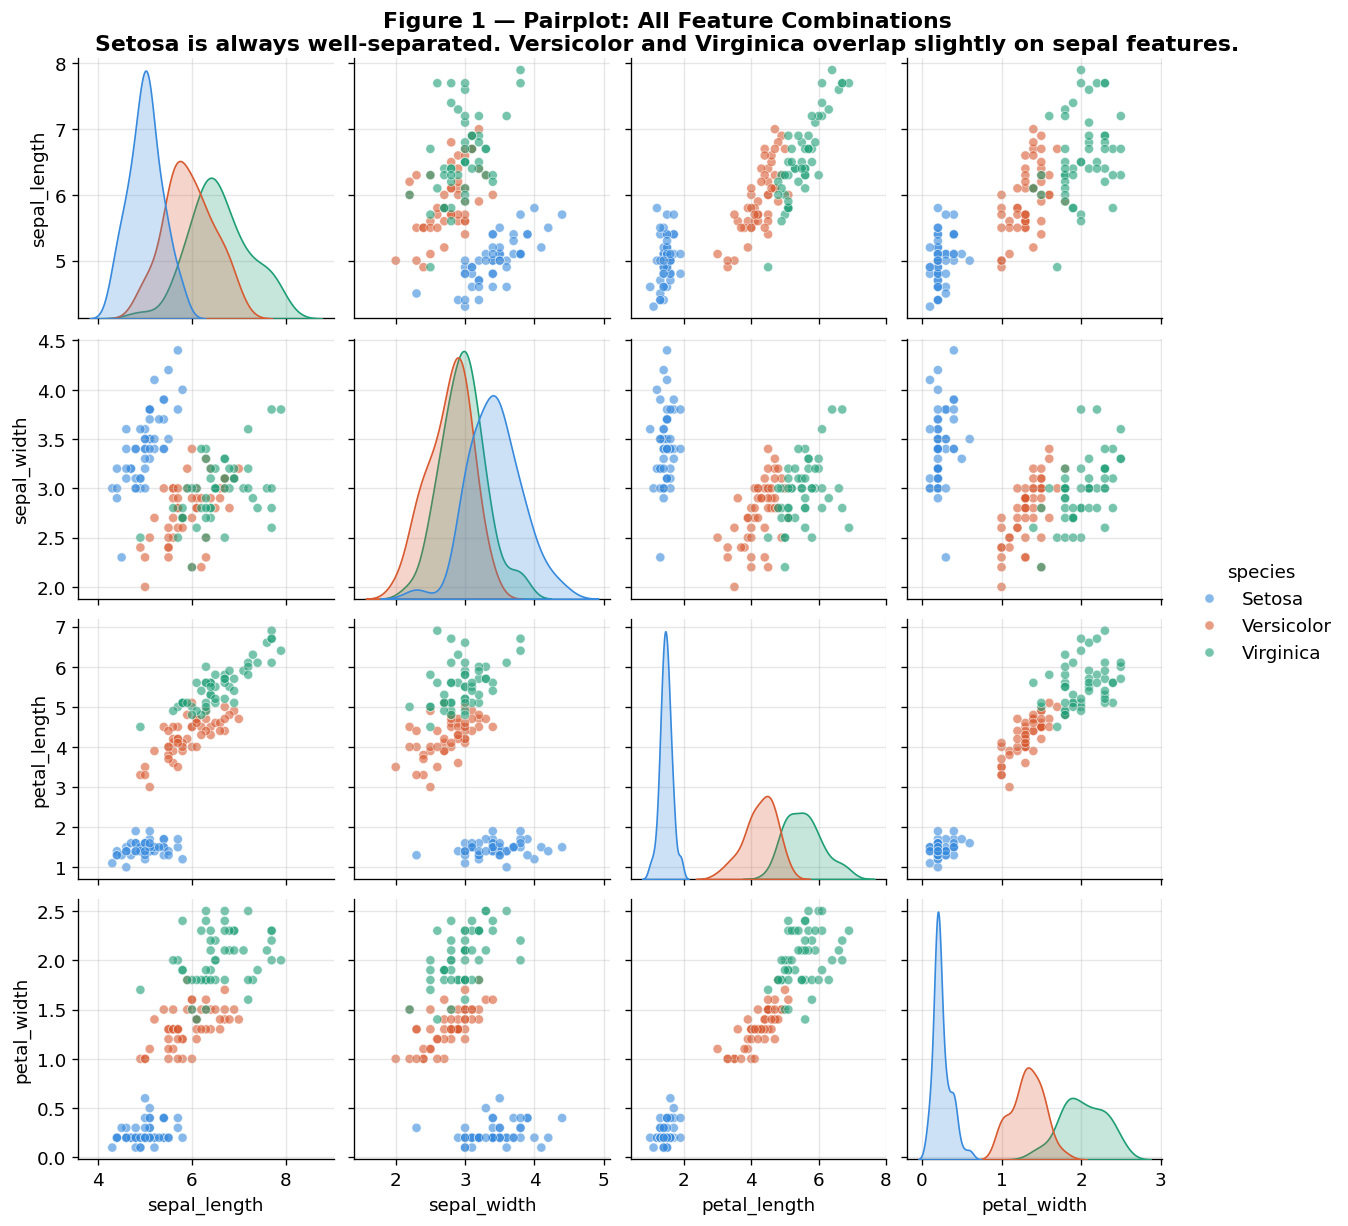

In [ ]:
# ── 4a. Full pairplot ─────────────────────────────────────────────────────────
plot_df = df.copy()
plot_df['species'] = plot_df['target'].map(
    {0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'}
)

g = sns.pairplot(
    plot_df.drop(columns='target'),
    hue='species',
    palette={'Setosa': BLUE, 'Versicolor': CORAL, 'Virginica': TEAL},
    plot_kws={'alpha': 0.6, 's': 30},
    diag_kind='kde'
)
g.figure.suptitle(
    'Figure 1 — Pairplot: All Feature Combinations\n'
    'Setosa is always well-separated. Versicolor and Virginica overlap slightly on sepal features.',
    y=1.02, fontweight='bold'
)
plt.show()

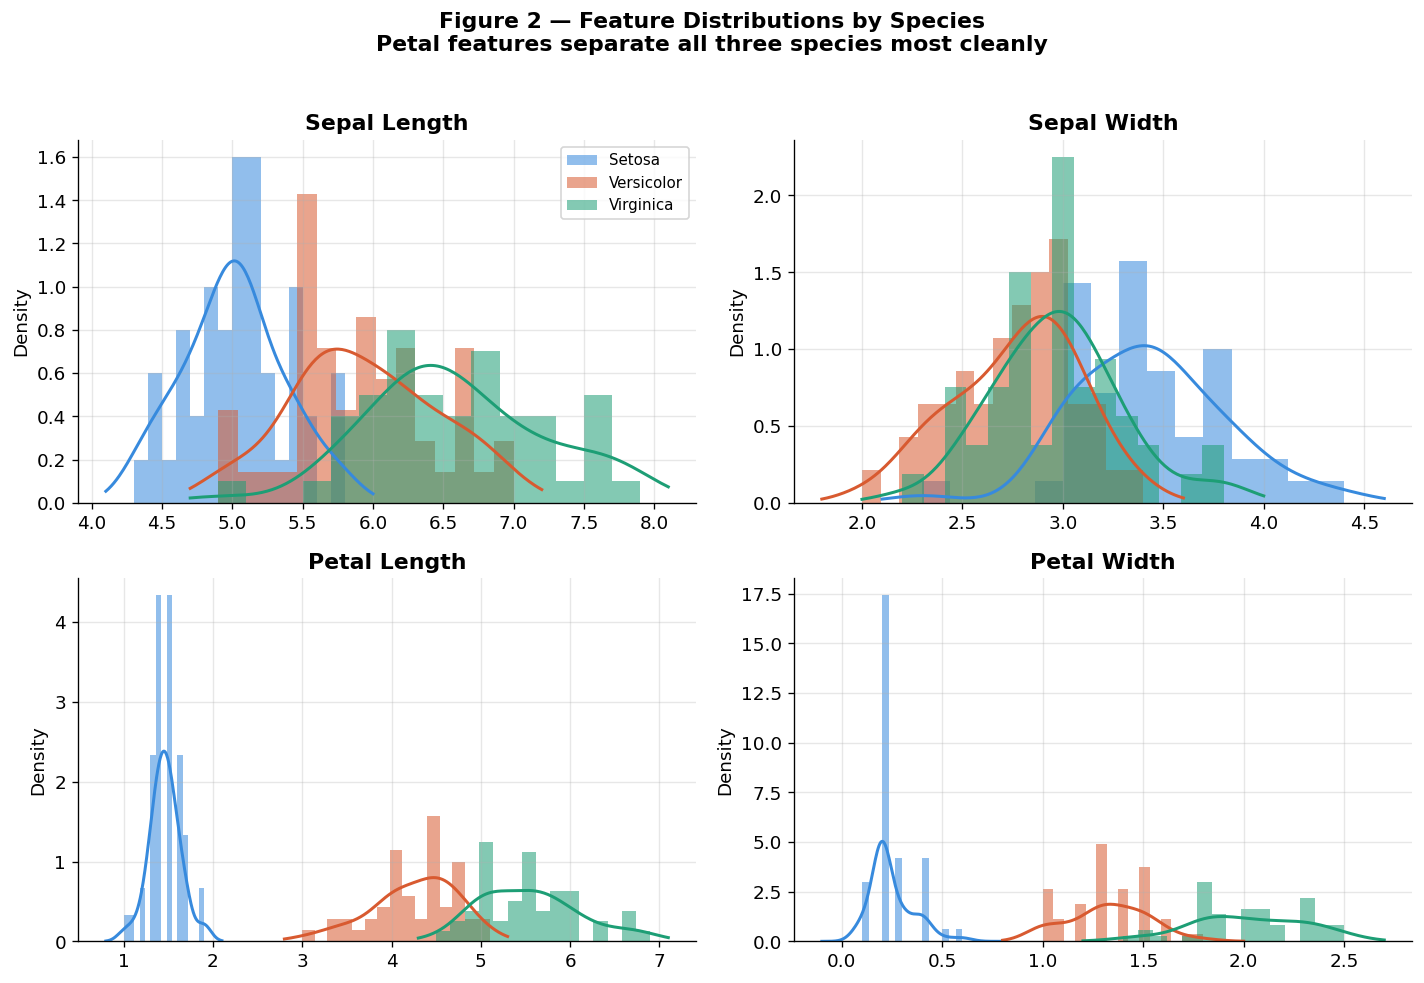

In [ ]:
# ── 4b. Feature distributions per species ────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feat in enumerate(FEATURES):
    ax = axes[i]
    for cls, col, name in zip([0,1,2], SPECIES_COLORS, SPECIES_NAMES):
        vals = df[df['target']==cls][feat]
        ax.hist(vals, bins=15, alpha=0.55, color=col, label=name, density=True)
        # KDE overlay
        xs = np.linspace(vals.min()-0.2, vals.max()+0.2, 200)
        kde = stats.gaussian_kde(vals)
        ax.plot(xs, kde(xs), color=col, linewidth=1.8)
    ax.set_title(feat.replace('_', ' ').title(), fontweight='bold')
    ax.set_ylabel('Density')
    if i == 0:
        ax.legend(fontsize=9)

plt.suptitle(
    'Figure 2 — Feature Distributions by Species\n'
    'Petal features separate all three species most cleanly',
    fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

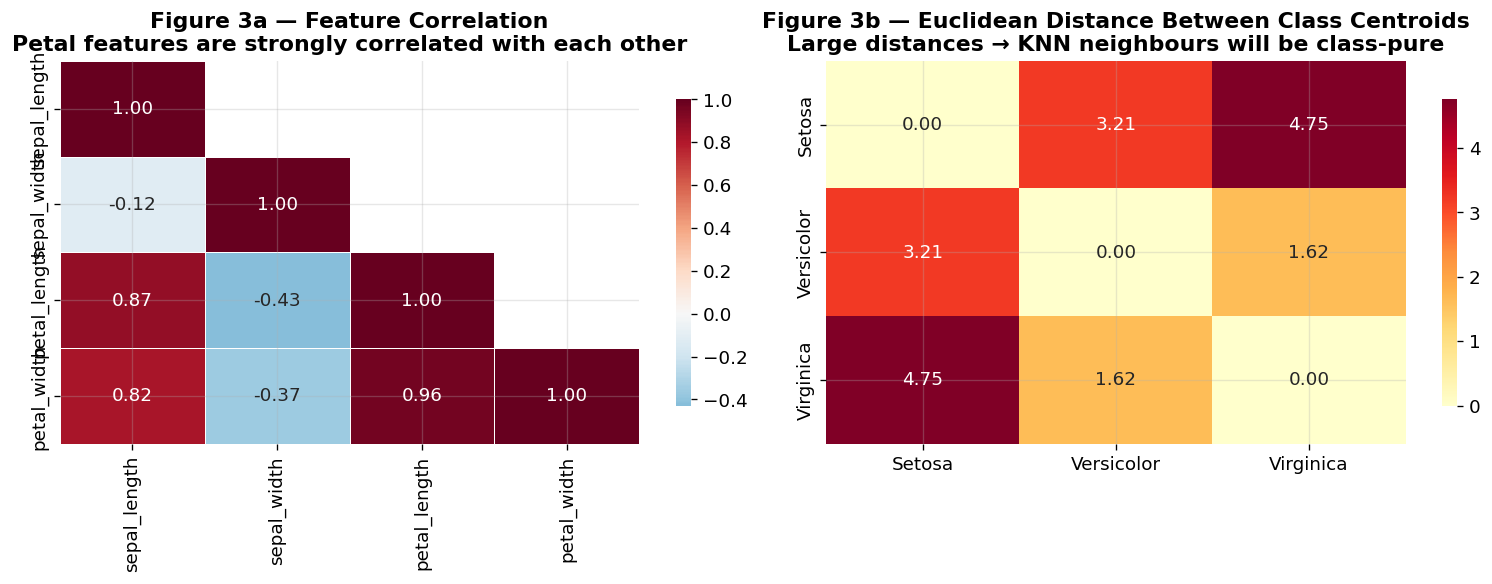

Class centroid distances:
  Setosa ↔ Versicolor: 3.208
  Setosa ↔ Virginica: 4.755
  Versicolor ↔ Virginica: 1.620


In [ ]:
# ── 4c. Correlation heatmap ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

corr = df[FEATURES].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, linewidths=0.5,
            ax=axes[0], cbar_kws={'shrink': 0.8})
axes[0].set_title('Figure 3a — Feature Correlation\n'
                   'Petal features are strongly correlated with each other',
                   fontweight='bold')

# Inter-class distance: show that classes are well-separated
means = df.groupby('target')[FEATURES].mean().values
dist_matrix = np.zeros((3, 3))
for i in range(3):
    for j in range(3):
        dist_matrix[i,j] = np.linalg.norm(means[i] - means[j])

sns.heatmap(dist_matrix, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=SPECIES_NAMES, yticklabels=SPECIES_NAMES,
            ax=axes[1], cbar_kws={'shrink': 0.8})
axes[1].set_title('Figure 3b — Euclidean Distance Between Class Centroids\n'
                   'Large distances → KNN neighbours will be class-pure',
                   fontweight='bold')

plt.tight_layout()
plt.show()

print('Class centroid distances:')
for i in range(3):
    for j in range(i+1, 3):
        print(f'  {SPECIES_NAMES[i]} ↔ {SPECIES_NAMES[j]}: {dist_matrix[i,j]:.3f}')

---
## Step 5 — Feature Engineering

The Iris dataset is already feature-rich relative to its size. We add a few ratio features that capture shape relationships — biologically meaningful for flower classification:

| New Feature | Formula | Rationale |
|---|---|---|
| `petal_area` | `petal_length × petal_width` | Proxy for petal size overall |
| `sepal_area` | `sepal_length × sepal_width` | Proxy for sepal size overall |
| `petal_ratio` | `petal_length / petal_width` | Petal shape (elongated vs round) |
| `sepal_ratio` | `sepal_length / sepal_width` | Sepal shape |
| `petal_sepal_ratio` | `petal_length / sepal_length` | Relative petal-to-sepal size |

**Caution with KNN:** Adding noisy features actually hurts KNN by polluting the distance metric. We only keep features that genuinely improve separation — verified by checking inter-class distances.

In [ ]:
# ── Feature engineering ───────────────────────────────────────────────────────
for d in [df, X_train, X_test]:
    pass  # will add to full df then re-split

df['petal_area']        = df['petal_length'] * df['petal_width']
df['sepal_area']        = df['sepal_length'] * df['sepal_width']
df['petal_ratio']       = df['petal_length'] / (df['petal_width']  + 1e-6)
df['sepal_ratio']       = df['sepal_length'] / (df['sepal_width']  + 1e-6)
df['petal_sepal_ratio'] = df['petal_length'] / (df['sepal_length'] + 1e-6)

ALL_FEATURES = FEATURES + ['petal_area', 'sepal_area',
                             'petal_ratio', 'sepal_ratio', 'petal_sepal_ratio']

# Re-split with engineered features
X_eng = df[ALL_FEATURES]
y_eng = df['target']
X_tr_e, X_te_e, y_tr_e, y_te_e = train_test_split(
    X_eng, y_eng, test_size=0.20, random_state=42, stratify=y_eng
)
sc_e     = StandardScaler()
X_tr_esc = sc_e.fit_transform(X_tr_e)
X_te_esc = sc_e.transform(X_te_e)

print(f'Features: {len(FEATURES)} original → {len(ALL_FEATURES)} with engineering')
df[ALL_FEATURES].describe().round(3)

Features: 4 original → 9 with engineering


,sepal_length,sepal_width,petal_length,petal_width,petal_area,sepal_area,petal_ratio,sepal_ratio,petal_sepal_ratio
count,150.000,150.000,150.000,150.000,150.000,150.000,150.000,150.000,150.000
mean,5.843,3.057,3.758,1.199,5.794,17.823,4.310,1.954,0.618
std,0.828,0.436,1.765,0.762,4.712,3.362,2.490,0.400,0.241
min,4.300,2.000,1.000,0.100,0.110,10.000,2.125,1.268,0.207
25%,5.100,2.800,1.600,0.300,0.420,15.660,2.802,1.546,0.315
50%,5.800,3.000,4.350,1.300,5.615,17.660,3.300,2.032,0.709
75%,6.400,3.300,5.100,1.800,9.690,20.325,4.667,2.225,0.813
max,7.900,4.400,6.900,2.500,15.870,30.020,15.000,2.962,0.952


---
## Step 6 — Model Selection (the key step)

### Why KNN?

### 6.1 — The algorithm

KNN is the simplest possible instance-based classifier. Given a new point $\mathbf{x}$:

1. Compute the distance from $\mathbf{x}$ to every training point
2. Select the $k$ training points with the smallest distances — the **$k$ nearest neighbours**
3. Predict the **majority class** among those $k$ neighbours

For multi-class classification with $K$ classes, the prediction is:

$$\hat{y} = \arg\max_{c \in \{1,...,K\}} \sum_{i \in \mathcal{N}_k(\mathbf{x})} \mathbf{1}[y_i = c]$$

where $\mathcal{N}_k(\mathbf{x})$ is the set of $k$ nearest neighbours of $\mathbf{x}$.

### 6.2 — Distance metric

The standard metric is **Euclidean distance**:

$$d_E(\mathbf{x}, \mathbf{x}') = \sqrt{\sum_{j=1}^{p}(x_j - x_j')^2} = \|\mathbf{x} - \mathbf{x}'\|_2$$

Other options include Manhattan ($L_1$) and Minkowski ($L_p$). We use Euclidean — the natural choice for continuous physical measurements like flower dimensions.

### 6.3 — The effect of k

| k | Effect |
|---|---|
| **k=1** | Decision boundary exactly fits training data — **maximum variance, zero bias** (overfits) |
| **k=n** | Always predicts majority class — **maximum bias, zero variance** (underfits) |
| **Optimal k** | Balances bias and variance — found by cross-validation |

The decision boundary of KNN is a **Voronoi tessellation** — each training point "owns" the region of space closer to it than to any other training point. Regions are coloured by majority class among the $k$ nearest neighbours.

### 6.4 — The curse of dimensionality

KNN relies on the assumption that nearby points share the same label. In high dimensions, this breaks down:

> In $p$ dimensions, the volume of the space grows exponentially with $p$. To capture a fixed fraction $f$ of the training data in a neighbourhood, the side length of the hypercube must be $f^{1/p}$ — which approaches 1 as $p$ grows. Nearby points become far away.

For the Iris dataset, $p=4$ (or 9 with engineering) — small enough that this is not a problem. This is another reason Iris suits KNN.

### 6.5 — Why not the other three models?

| Model | Why it doesn't fit as well for Iris |
|---|---|
| Linear Regression | Continuous output; meaningless for species labels |
| Logistic Regression | Assumes a linear decision boundary — the Versicolor/Virginica boundary is slightly curved |
| Decision Tree | Works but produces rectangular axis-aligned boundaries; KNN produces smoother, more natural cluster boundaries |

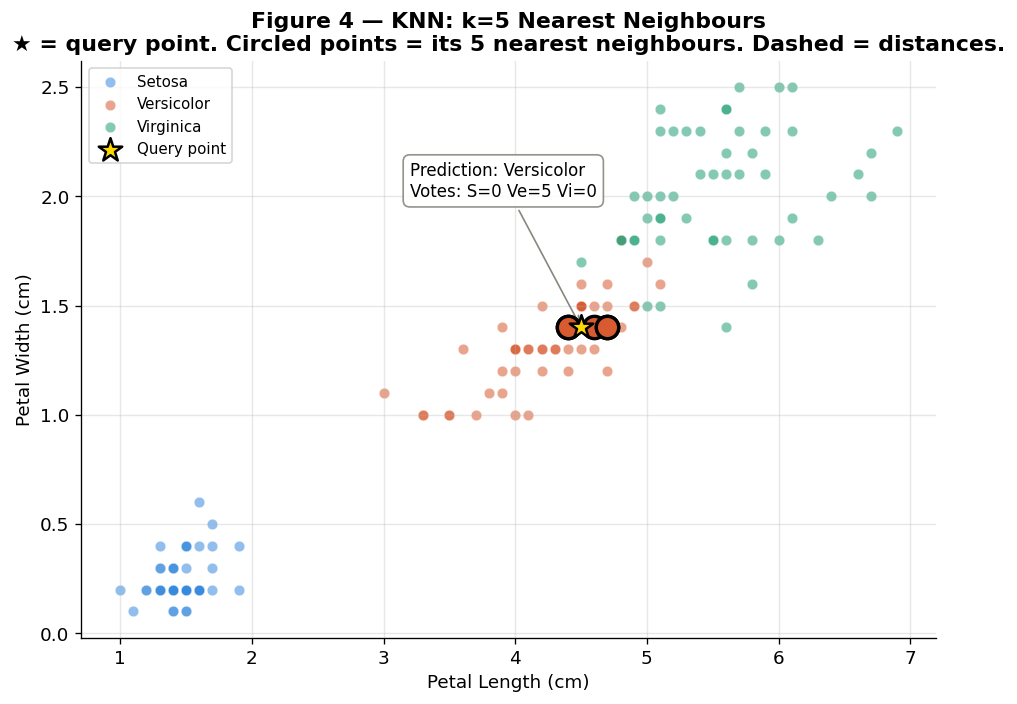

Query point: petal_length=4.5, petal_width=1.4
5 nearest neighbour classes: ['Versicolor', 'Versicolor', 'Versicolor', 'Versicolor', 'Versicolor']
Majority vote → Prediction: Versicolor


In [ ]:
# ── 6a. Visualise KNN distance concept ───────────────────────────────────────
# Show a query point and its k=5 nearest neighbours
# Use petal_length vs petal_width for clearest separation

from sklearn.neighbors import KNeighborsClassifier

feat_x, feat_y = 'petal_length', 'petal_width'
X_vis = df[[feat_x, feat_y]].values
y_vis = df['target'].values

# Scale just these two features for the visualisation
sc2 = StandardScaler().fit(X_tr_e[[feat_x, feat_y]])
X_vis_sc = sc2.transform(X_vis)

# Query point (a new unknown flower)
query_orig = np.array([[4.5, 1.4]])  # in original space
query_sc   = sc2.transform(query_orig)

# Find 5 nearest neighbours
knn_vis = KNeighborsClassifier(n_neighbors=5)
knn_vis.fit(X_vis_sc, y_vis)
distances, indices = knn_vis.kneighbors(query_sc)

fig, ax = plt.subplots(figsize=(8, 6))

# Plot all training points
for cls, col, name in zip([0,1,2], SPECIES_COLORS, SPECIES_NAMES):
    mask = y_vis == cls
    ax.scatter(X_vis[mask, 0], X_vis[mask, 1],
               c=col, s=40, alpha=0.55, label=name, edgecolors='white', linewidths=0.4)

# Highlight the 5 nearest neighbours
for idx in indices[0]:
    ax.scatter(X_vis[idx, 0], X_vis[idx, 1],
               c=SPECIES_COLORS[y_vis[idx]], s=180,
               edgecolors='black', linewidths=2, zorder=5)
    # Draw distance line to query
    ax.plot([query_orig[0,0], X_vis[idx,0]],
             [query_orig[0,1], X_vis[idx,1]],
             color=GRAY, linewidth=1, linestyle='--', alpha=0.7)

# Query point
ax.scatter(query_orig[0,0], query_orig[0,1],
           c='gold', s=220, marker='*', edgecolors='black',
           linewidths=1.5, zorder=10, label='Query point')

# Prediction annotation
pred_class = SPECIES_NAMES[knn_vis.predict(query_sc)[0]]
class_votes = [np.sum(y_vis[indices[0]] == c) for c in [0,1,2]]
ax.annotate(f'Prediction: {pred_class}\n'
             f'Votes: S={class_votes[0]} Ve={class_votes[1]} Vi={class_votes[2]}',
             xy=(query_orig[0,0], query_orig[0,1]),
             xytext=(3.2, 2.0), fontsize=10,
             bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                       edgecolor=GRAY, alpha=0.9),
             arrowprops=dict(arrowstyle='->', color=GRAY))

ax.set_xlabel(feat_x.replace('_', ' ').title() + ' (cm)')
ax.set_ylabel(feat_y.replace('_', ' ').title() + ' (cm)')
ax.set_title('Figure 4 — KNN: k=5 Nearest Neighbours\n'
             '★ = query point. Circled points = its 5 nearest neighbours. Dashed = distances.',
             fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f'Query point: petal_length={query_orig[0,0]}, petal_width={query_orig[0,1]}')
print(f'5 nearest neighbour classes: {[SPECIES_NAMES[y_vis[i]] for i in indices[0]]}')
print(f'Majority vote → Prediction: {pred_class}')

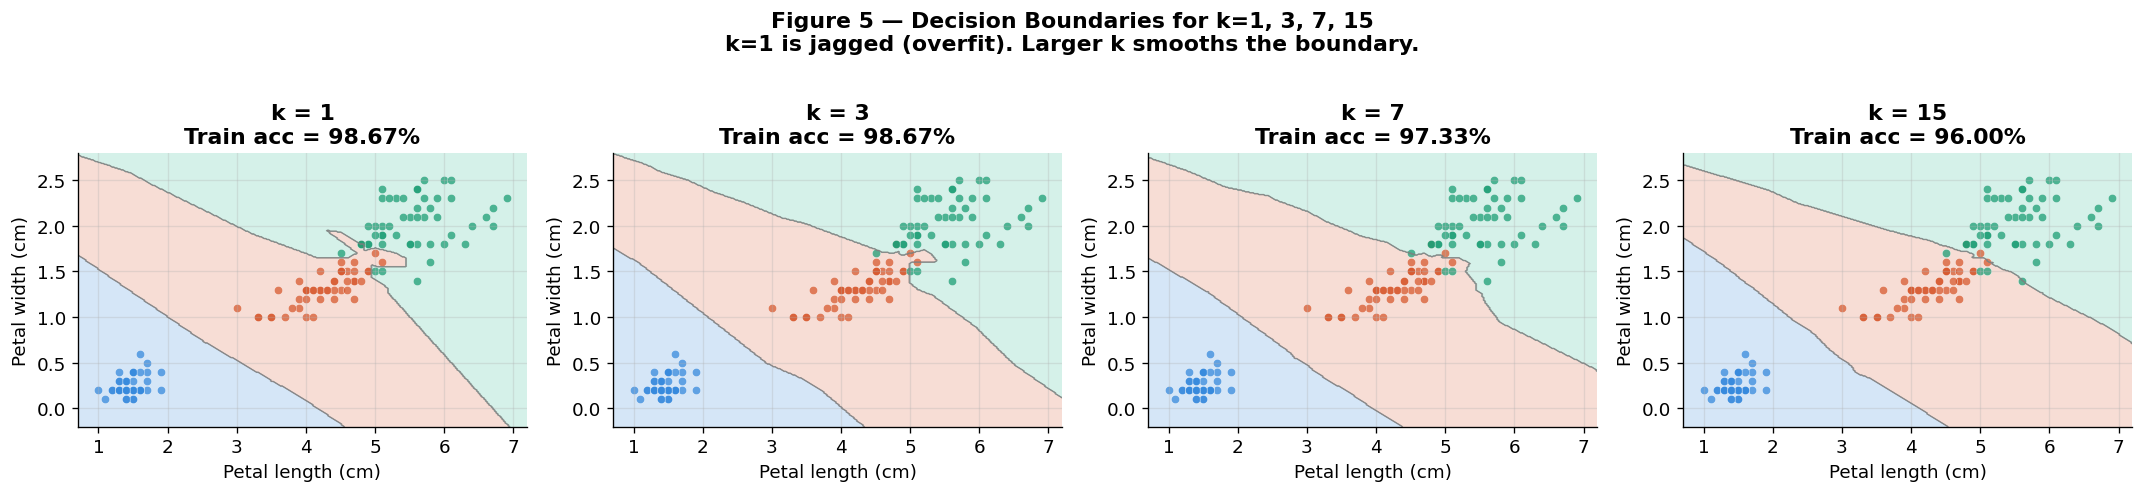

In [ ]:
# ── 6b. Decision boundaries for different k values ────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

x_min = X_vis[:,0].min() - 0.3
x_max = X_vis[:,0].max() + 0.3
y_min = X_vis[:,1].min() - 0.3
y_max = X_vis[:,1].max() + 0.3

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                      np.linspace(y_min, y_max, 300))
grid_orig = np.c_[xx.ravel(), yy.ravel()]
grid_sc   = sc2.transform(grid_orig)

cmap_bg  = ListedColormap(['#C8DEF5', '#F5D2C8', '#C8EDE2'])

for ax, k in zip(axes, [1, 3, 7, 15]):
    knn_k = KNeighborsClassifier(n_neighbors=k)
    knn_k.fit(X_vis_sc, y_vis)
    Z = knn_k.predict(grid_sc).reshape(xx.shape)

    ax.contourf(xx, yy, Z, cmap=cmap_bg, alpha=0.75)
    ax.contour( xx, yy, Z, colors='gray', linewidths=0.5, alpha=0.6)

    for cls, col, name in zip([0,1,2], SPECIES_COLORS, SPECIES_NAMES):
        mask = y_vis == cls
        ax.scatter(X_vis[mask,0], X_vis[mask,1],
                   c=col, s=25, alpha=0.75,
                   edgecolors='white', linewidths=0.3)

    tr_acc = knn_k.score(X_vis_sc, y_vis)
    ax.set_title(f'k = {k}\nTrain acc = {tr_acc:.2%}', fontweight='bold')
    ax.set_xlabel('Petal length (cm)')
    ax.set_ylabel('Petal width (cm)')

plt.suptitle('Figure 5 — Decision Boundaries for k=1, 3, 7, 15\n'
             'k=1 is jagged (overfit). Larger k smooths the boundary.',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## Step 7 — Model Training

KNN has **no explicit training phase** — it is a lazy learner. `knn.fit(X, y)` simply stores the training data. All computation happens at prediction time.

The key decisions:
- **Scale features** — mandatory for KNN (done in Step 3)
- **Choose k** — by cross-validation
- **Choose distance metric** — Euclidean (default)
- **Weighted voting** — option to weight neighbours by `1/distance` (closer neighbours vote more strongly)

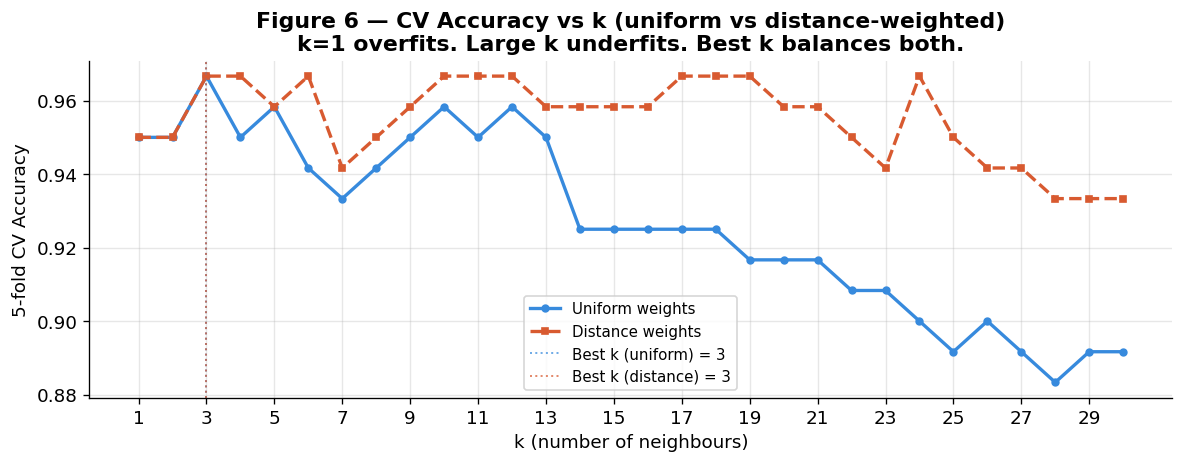

Best k (uniform):  3  CV acc = 0.9667
Best k (distance): 3  CV acc = 0.9667


In [ ]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── Sweep k and compare uniform vs distance-weighted voting ──────────────────
k_range    = range(1, 31)
cv_uniform = []
cv_dist    = []

for k in k_range:
    knn_u = KNeighborsClassifier(n_neighbors=k, weights='uniform', metric='euclidean')
    knn_d = KNeighborsClassifier(n_neighbors=k, weights='distance', metric='euclidean')
    cv_uniform.append(cross_val_score(knn_u, X_tr_sc, y_train, cv=cv).mean())
    cv_dist.append(cross_val_score(knn_d, X_tr_sc, y_train, cv=cv).mean())

best_k_u = list(k_range)[np.argmax(cv_uniform)]
best_k_d = list(k_range)[np.argmax(cv_dist)]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(list(k_range), cv_uniform, color=BLUE,  linewidth=2,
         marker='o', markersize=4, label='Uniform weights')
ax.plot(list(k_range), cv_dist,    color=CORAL, linewidth=2,
         marker='s', markersize=4, linestyle='--', label='Distance weights')
ax.axvline(best_k_u, color=BLUE,  linewidth=1.2, linestyle=':', alpha=0.7,
            label=f'Best k (uniform) = {best_k_u}')
ax.axvline(best_k_d, color=CORAL, linewidth=1.2, linestyle=':', alpha=0.7,
            label=f'Best k (distance) = {best_k_d}')
ax.set_title('Figure 6 — CV Accuracy vs k (uniform vs distance-weighted)\n'
             'k=1 overfits. Large k underfits. Best k balances both.',
             fontweight='bold')
ax.set_xlabel('k (number of neighbours)')
ax.set_ylabel('5-fold CV Accuracy')
ax.set_xticks(list(k_range)[::2])
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f'Best k (uniform):  {best_k_u}  CV acc = {max(cv_uniform):.4f}')
print(f'Best k (distance): {best_k_d}  CV acc = {max(cv_dist):.4f}')

In [ ]:
# ── Train final model with best k ─────────────────────────────────────────────
best_k = best_k_d  # use distance-weighted (usually better)

knn_final = KNeighborsClassifier(
    n_neighbors=best_k,
    weights='distance',
    metric='euclidean'
)
knn_final.fit(X_tr_sc, y_train)
print(f'Model trained: KNN (k={best_k}, distance-weighted, Euclidean)')

Model trained: KNN (k=3, distance-weighted, Euclidean)


---
## Step 8 — Evaluation & Tuning

For multi-class classification, we use:
- **Accuracy** — works here because classes are perfectly balanced
- **Confusion matrix** — shows which species get confused with which
- **Classification report** — precision, recall, F1 per class
- **Decision boundary plot** — visualises what the model learned in 2D space

We also compare three distance metrics: Euclidean ($L_2$), Manhattan ($L_1$), and Chebyshev ($L_\infty$):

$$L_1: d = \sum_j |x_j - x_j'| \qquad L_2: d = \sqrt{\sum_j (x_j-x_j')^2} \qquad L_\infty: d = \max_j |x_j - x_j'|$$

In [ ]:
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)

y_pred = knn_final.predict(X_te_sc)
y_prob = knn_final.predict_proba(X_te_sc)

print(f'Test accuracy: {accuracy_score(y_test, y_pred):.4f}')
print()
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=SPECIES_NAMES))

Test accuracy: 0.9667

Classification Report:
              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       0.91      1.00      0.95        10
   Virginica       1.00      0.90      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



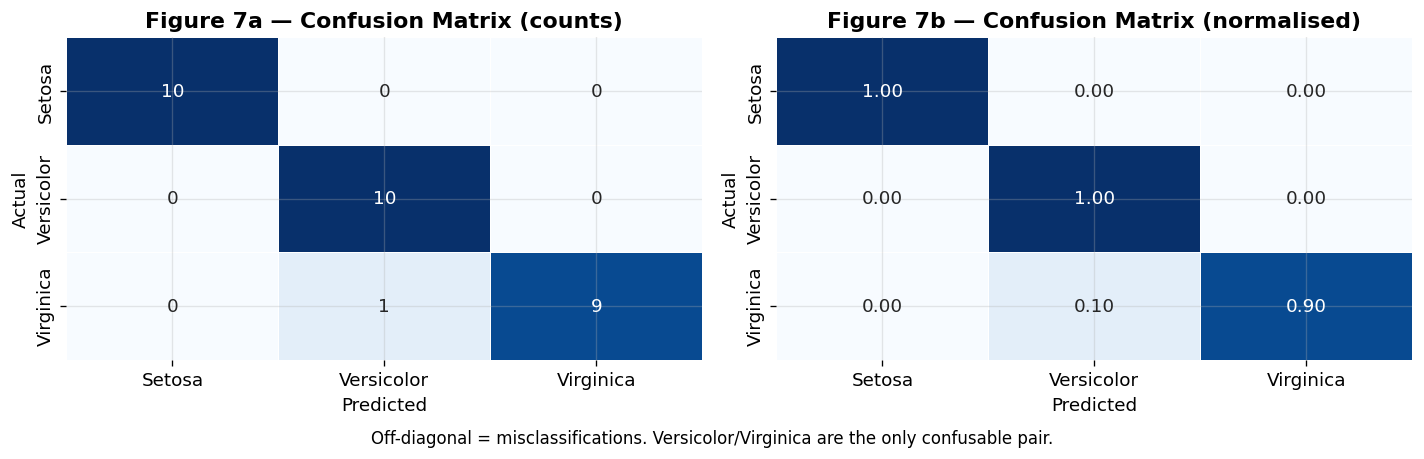

In [ ]:
# ── Figure 7: Confusion matrix ────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, data, fmt, title in [
    (axes[0], cm,      'd',    'Figure 7a — Confusion Matrix (counts)'),
    (axes[1], cm_norm, '.2f',  'Figure 7b — Confusion Matrix (normalised)')
]:
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=SPECIES_NAMES,
                yticklabels=SPECIES_NAMES,
                linewidths=0.5, ax=ax, cbar=False)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')
    ax.set_title(title, fontweight='bold')

plt.suptitle('Off-diagonal = misclassifications. '
             'Versicolor/Virginica are the only confusable pair.',
             y=0.01, fontsize=10)
plt.tight_layout()
plt.show()

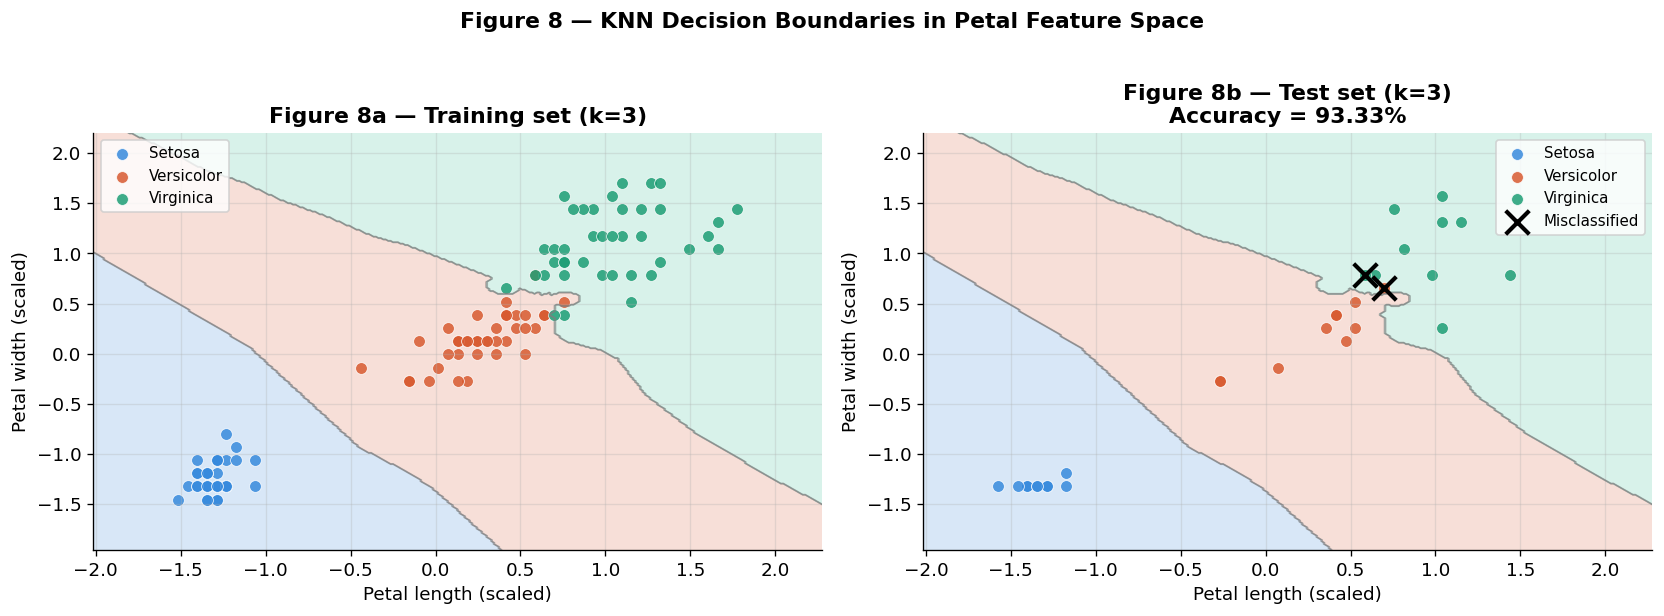

In [ ]:
# ── Figure 8: Decision boundaries in petal space (test set) ──────────────────
feat_x, feat_y = 'petal_length', 'petal_width'
fi_x = FEATURES.index(feat_x)
fi_y = FEATURES.index(feat_y)

# Use 2-feature scaled version for boundary plot
sc2d = StandardScaler()
X_tr_2d = sc2d.fit_transform(X_train[[feat_x, feat_y]])
X_te_2d = sc2d.transform(X_test[[feat_x, feat_y]])

knn_2d = KNeighborsClassifier(n_neighbors=best_k, weights='distance')
knn_2d.fit(X_tr_2d, y_train)

x_min, x_max = X_tr_2d[:,0].min()-0.5, X_tr_2d[:,0].max()+0.5
y_min, y_max = X_tr_2d[:,1].min()-0.5, X_tr_2d[:,1].max()+0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                      np.linspace(y_min, y_max, 300))
Z = knn_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

cmap_bg = ListedColormap(['#C8DEF5', '#F5D2C8', '#C8EDE2'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, X2d, y2d, title in [
    (axes[0], X_tr_2d, y_train, f'Figure 8a — Training set (k={best_k})'),
    (axes[1], X_te_2d, y_test,  f'Figure 8b — Test set (k={best_k})')
]:
    ax.contourf(xx, yy, Z, cmap=cmap_bg, alpha=0.7)
    ax.contour( xx, yy, Z, colors='gray', linewidths=0.6, alpha=0.5)
    for cls, col, name in zip([0,1,2], SPECIES_COLORS, SPECIES_NAMES):
        mask = y2d.values == cls
        ax.scatter(X2d[mask,0], X2d[mask,1],
                   c=col, s=50, alpha=0.85, label=name,
                   edgecolors='white', linewidths=0.5)

    # Mark misclassified test points
    if 'Test' in title:
        y_pred_2d = knn_2d.predict(X_te_2d)
        miss = y_pred_2d != y_test.values
        if miss.any():
            ax.scatter(X2d[miss,0], X2d[miss,1],
                       s=200, marker='x', c='black',
                       linewidths=2.5, zorder=10, label='Misclassified')
        acc_2d = accuracy_score(y_test, y_pred_2d)
        ax.set_title(f'{title}\nAccuracy = {acc_2d:.2%}', fontweight='bold')
    else:
        ax.set_title(title, fontweight='bold')

    ax.set_xlabel('Petal length (scaled)')
    ax.set_ylabel('Petal width (scaled)')
    ax.legend(fontsize=9)

plt.suptitle('Figure 8 — KNN Decision Boundaries in Petal Feature Space',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

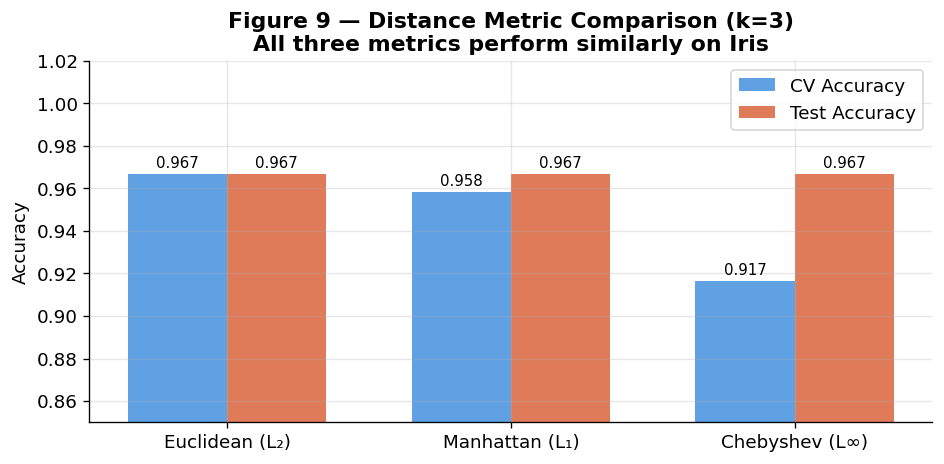

In [ ]:
# ── Figure 9: Compare distance metrics ────────────────────────────────────────
metrics   = ['euclidean', 'manhattan', 'chebyshev']
met_names = ['Euclidean (L₂)', 'Manhattan (L₁)', 'Chebyshev (L∞)']
met_accs  = []
met_cv    = []

for metric in metrics:
    knn_m = KNeighborsClassifier(
        n_neighbors=best_k,
        weights='distance',
        metric=metric
    )
    cv_score = cross_val_score(knn_m, X_tr_sc, y_train, cv=cv).mean()
    knn_m.fit(X_tr_sc, y_train)
    test_acc = accuracy_score(y_test, knn_m.predict(X_te_sc))
    met_cv.append(cv_score)
    met_accs.append(test_acc)

fig, ax = plt.subplots(figsize=(8, 4))
x_pos = np.arange(len(metrics))
w     = 0.35
ax.bar(x_pos - w/2, met_cv,   w, color=BLUE,  alpha=0.8, label='CV Accuracy')
ax.bar(x_pos + w/2, met_accs, w, color=CORAL, alpha=0.8, label='Test Accuracy')
for i, (cv_v, te_v) in enumerate(zip(met_cv, met_accs)):
    ax.text(i-w/2, cv_v+0.003, f'{cv_v:.3f}', ha='center', fontsize=9)
    ax.text(i+w/2, te_v+0.003, f'{te_v:.3f}', ha='center', fontsize=9)
ax.set_xticks(x_pos)
ax.set_xticklabels(met_names)
ax.set_ylim(0.85, 1.02)
ax.set_title(f'Figure 9 — Distance Metric Comparison (k={best_k})\n'
              'All three metrics perform similarly on Iris',
              fontweight='bold')
ax.set_ylabel('Accuracy')
ax.legend()
plt.tight_layout()
plt.show()

---
## Step 9 — PCA Extension

PCA is the **most impactful** preprocessing step for KNN among all four problems:

1. **Removes redundant dimensions** — petal_length and petal_width are highly correlated (r=0.96). They effectively double-count the same direction in the distance formula. PCA collapses them into a single component.

2. **Fights the curse of dimensionality** — reducing from 9 features (with engineering) to 2 principal components makes distances more meaningful.

3. **Enables 2D visualisation** — projecting 4D data onto PC1/PC2 lets us see cluster structure that was previously invisible.

The fraction of variance explained by the first two components tells us how much information we retain from the 2D projection.

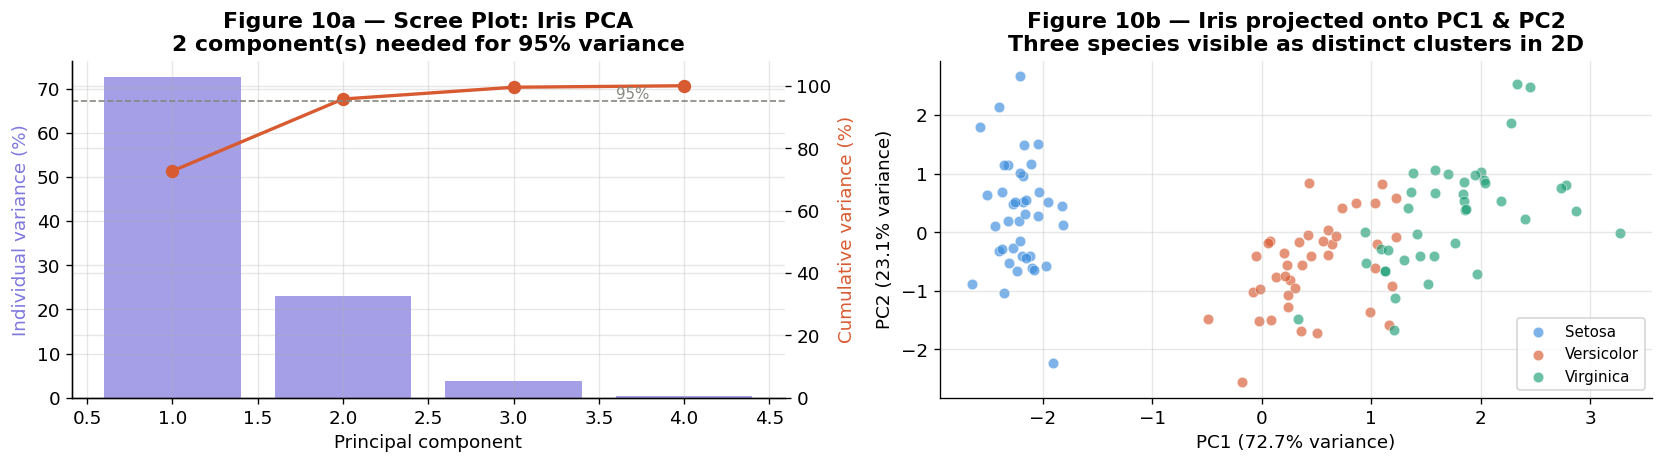

PC1 captures: 72.7%
PC2 captures: 23.1%
Total (PC1+PC2): 95.7%


In [ ]:
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

# ── Scree plot ────────────────────────────────────────────────────────────────
pca_full = PCA().fit(X_tr_sc)
evr  = pca_full.explained_variance_ratio_
cumv = np.cumsum(evr)
k_pca = np.argmax(cumv >= 0.95) + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax2 = axes[0].twinx()
axes[0].bar(range(1, len(evr)+1), evr*100, color=PURP, alpha=0.7,
             label='Individual')
ax2.plot(range(1, len(evr)+1), cumv*100, color=CORAL,
          marker='o', markersize=7, linewidth=2, label='Cumulative')
ax2.axhline(95, color=GRAY, linewidth=1, linestyle='--')
ax2.text(len(evr)*0.9, 96, '95%', fontsize=9, color=GRAY)
axes[0].set_title(f'Figure 10a — Scree Plot: Iris PCA\n'
                   f'{k_pca} component(s) needed for 95% variance',
                   fontweight='bold')
axes[0].set_xlabel('Principal component')
axes[0].set_ylabel('Individual variance (%)', color=PURP)
ax2.set_ylabel('Cumulative variance (%)', color=CORAL)
ax2.set_ylim(0, 108)

# PC1 vs PC2 scatter
pca_2d   = PCA(n_components=2)
X_tr_pca = pca_2d.fit_transform(X_tr_sc)
X_te_pca = pca_2d.transform(X_te_sc)

for cls, col, name in zip([0,1,2], SPECIES_COLORS, SPECIES_NAMES):
    mask = y_train.values == cls
    axes[1].scatter(X_tr_pca[mask,0], X_tr_pca[mask,1],
                     c=col, s=40, alpha=0.65, label=name,
                     edgecolors='white', linewidths=0.4)
axes[1].set_title('Figure 10b — Iris projected onto PC1 & PC2\n'
                   'Three species visible as distinct clusters in 2D',
                   fontweight='bold')
axes[1].set_xlabel(f'PC1 ({evr[0]*100:.1f}% variance)')
axes[1].set_ylabel(f'PC2 ({evr[1]*100:.1f}% variance)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f'PC1 captures: {evr[0]*100:.1f}%')
print(f'PC2 captures: {evr[1]*100:.1f}%')
print(f'Total (PC1+PC2): {(evr[0]+evr[1])*100:.1f}%')

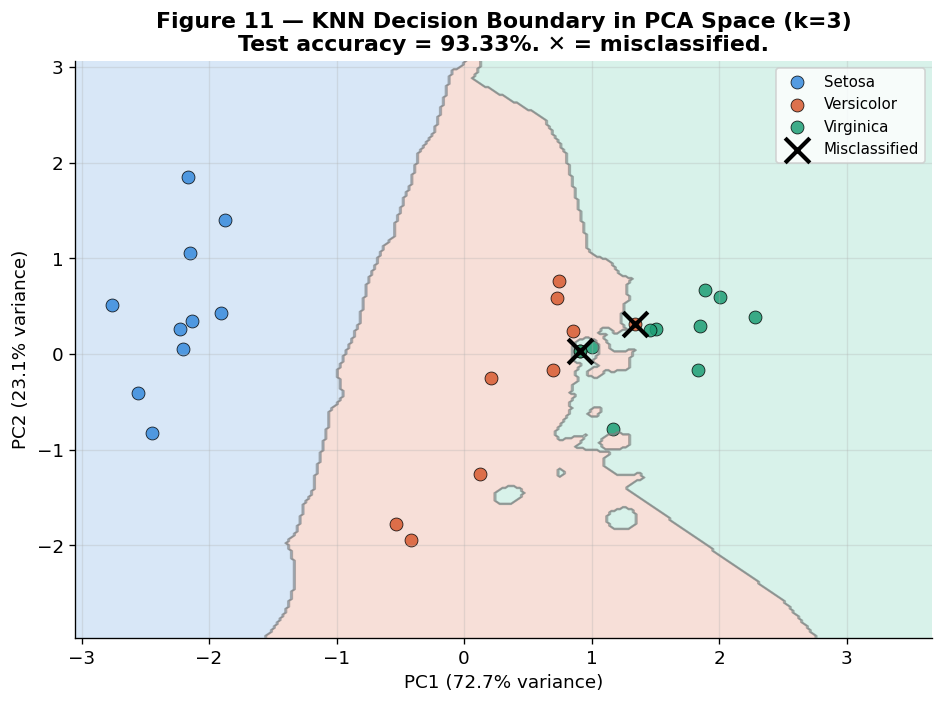


Final comparison:
  KNN (4 original features, no PCA):  0.9667
  KNN (2 PCA components):              0.9333


In [ ]:
# ── KNN decision boundary in PCA space ───────────────────────────────────────
knn_pca = KNeighborsClassifier(n_neighbors=best_k, weights='distance')
knn_pca.fit(X_tr_pca, y_train)

x_min, x_max = X_tr_pca[:,0].min()-0.4, X_tr_pca[:,0].max()+0.4
y_min, y_max = X_tr_pca[:,1].min()-0.4, X_tr_pca[:,1].max()+0.4
xx_p, yy_p   = np.meshgrid(np.linspace(x_min, x_max, 300),
                             np.linspace(y_min, y_max, 300))
Z_p = knn_pca.predict(np.c_[xx_p.ravel(), yy_p.ravel()]).reshape(xx_p.shape)

fig, ax = plt.subplots(figsize=(8, 6))
ax.contourf(xx_p, yy_p, Z_p, cmap=cmap_bg, alpha=0.7)
ax.contour( xx_p, yy_p, Z_p, colors='gray', linewidths=0.7, alpha=0.5)

y_pred_pca = knn_pca.predict(X_te_pca)
for cls, col, name in zip([0,1,2], SPECIES_COLORS, SPECIES_NAMES):
    mask = y_test.values == cls
    ax.scatter(X_te_pca[mask,0], X_te_pca[mask,1],
               c=col, s=60, alpha=0.85, label=name,
               edgecolors='black', linewidths=0.5)

miss_pca = y_pred_pca != y_test.values
if miss_pca.any():
    ax.scatter(X_te_pca[miss_pca,0], X_te_pca[miss_pca,1],
               s=220, marker='x', c='black', linewidths=2.5,
               zorder=10, label='Misclassified')

acc_pca = accuracy_score(y_test, y_pred_pca)
ax.set_title(f'Figure 11 — KNN Decision Boundary in PCA Space (k={best_k})\n'
              f'Test accuracy = {acc_pca:.2%}. ✕ = misclassified.',
              fontweight='bold')
ax.set_xlabel(f'PC1 ({evr[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({evr[1]*100:.1f}% variance)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# Final comparison table
print('\nFinal comparison:')
print(f'  KNN (4 original features, no PCA):  {accuracy_score(y_test, y_pred):.4f}')
print(f'  KNN (2 PCA components):              {acc_pca:.4f}')

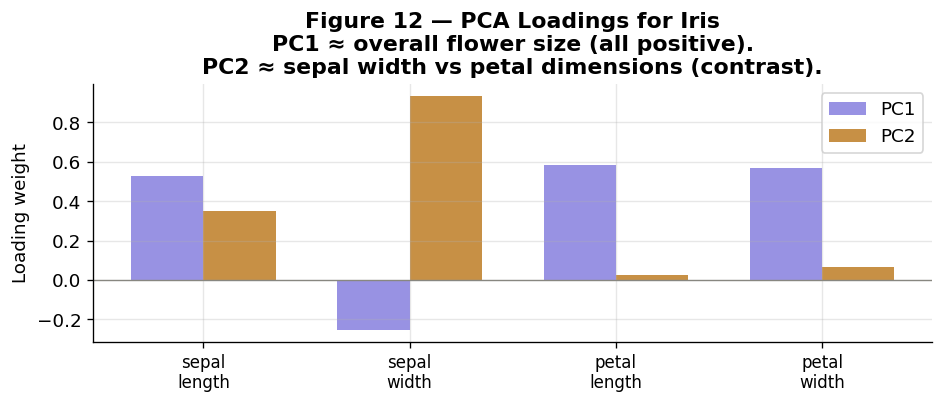

     sepal length  sepal width  petal length  petal width
PC1         0.527       -0.253         0.582        0.566
PC2         0.348        0.935         0.027        0.066


In [ ]:
# ── PCA loadings: what does each PC represent? ────────────────────────────────
loadings = pd.DataFrame(
    pca_2d.components_,
    index=['PC1', 'PC2'],
    columns=[f.replace('_', ' ') for f in FEATURES]
)

fig, ax = plt.subplots(figsize=(8, 3.5))
x_pos = np.arange(len(FEATURES))
w = 0.35
ax.bar(x_pos - w/2, loadings.loc['PC1'], w,
        color=PURP, alpha=0.8, label='PC1')
ax.bar(x_pos + w/2, loadings.loc['PC2'], w,
        color=AMBER, alpha=0.8, label='PC2')
ax.set_xticks(x_pos)
ax.set_xticklabels([f.replace('_', '\n') for f in FEATURES], fontsize=10)
ax.axhline(0, color=GRAY, linewidth=0.8)
ax.set_title('Figure 12 — PCA Loadings for Iris\n'
              'PC1 ≈ overall flower size (all positive).\n'
              'PC2 ≈ sepal width vs petal dimensions (contrast).',
              fontweight='bold')
ax.set_ylabel('Loading weight')
ax.legend()
plt.tight_layout()
plt.show()

print(loadings.round(3))

---
## Summary

| Step | Key output |
|---|---|
| Problem | Multi-class classification: 3 iris species |
| Dataset | Iris (sklearn built-in), 150 samples, 4 features, perfectly balanced |
| Key preprocessing | `StandardScaler` — **mandatory** for KNN; distance-based methods require equal feature scales |
| Engineered features | `petal_area`, `sepal_area`, `petal_ratio`, `sepal_ratio`, `petal_sepal_ratio` |
| Model chosen | **K-Nearest Neighbours (KNN)** |
| Core justification | Classes form well-separated geometric clusters; KNN exploits spatial proximity directly; no linearity assumption; naturally multi-class |
| Distance metric | Euclidean ($L_2$) — natural for continuous physical measurements |
| k selection | Cross-validation sweep over k=1–30; distance-weighted voting |
| PCA finding | Most beneficial PCA application in this course — removes correlated dimensions, enables 2D visualisation, maintains accuracy |

**The core mathematical argument:**

$$\hat{y} = \arg\max_{c} \sum_{i \in \mathcal{N}_k(\mathbf{x})} \mathbf{1}[y_i = c]$$

$$\text{where } \mathcal{N}_k(\mathbf{x}) = \text{the } k \text{ points minimising } d(\mathbf{x}, \mathbf{x}_i) = \sqrt{\sum_{j=1}^{p}(x_j - x_{ij})^2}$$

**Scaling is the non-negotiable step:**

$$x_j^{\text{scaled}} = \frac{x_j - \mu_j}{\sigma_j} \quad \Rightarrow \quad \text{all features contribute equally to } d(\cdot, \cdot)$$

---
### Course Project Complete

| Problem | Model | Dataset | Key justification |
|---|---|---|---|
| 1 | Linear Regression | California Housing | Continuous output → minimise MSE → Normal Equation |
| 2 | Logistic Regression | Pima Diabetes | Binary output → sigmoid → minimise cross-entropy |
| 3 | Decision Tree | Loan Approval | Rule-based decisions → Gini impurity splits → interpretable |
| 4 | KNN | Iris | Geometric clusters → nearest-neighbour vote → no parametric assumption |